In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [15]:
Data=r"C:\Users\PRINCE\OneDrive\Desktop\study matieral\DA\Projects\Project-1\data\archive (1)\SuperMarket_Analusis.csv"
df=pd.read_csv(Data)

In [16]:

df["Date"] = pd.to_datetime(df["Date"])
 
print("Data loaded:", df.shape[0], "rows")
print(df.columns.tolist())

Data loaded: 1000 rows
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'Rating', ' UnitPrice ', 'grossincome', 'cogs', 'sales']


In [17]:
df.columns = (
    df.columns
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [18]:
df = df.rename(columns={'sales': 'sales_lower'}) 

In [19]:
# Create a SQLite database and push data into it

n = sqlite3.connect(":memory:")
df.to_sql("sales", n, index=False, if_exists="replace")

1000

In [20]:
print(df['Time'].head())

0     1:08:00 PM
1    10:29:00 AM
2     1:23:00 PM
3     8:33:00 PM
4    10:37:00 AM
Name: Time, dtype: object



--- Q1: Monthly revenue by product line ---
     month            Product_line     revenue
0  2019-01       Sports and travel  21667.0230
1  2019-03      Home and lifestyle  20932.7895
2  2019-01      Home and lifestyle  20494.7400
3  2019-02      Food and beverages  20000.3580
4  2019-03       Sports and travel  19646.1930
5  2019-01      Food and beverages  19570.5300
6  2019-01     Fashion accessories  19345.1160
7  2019-02     Fashion accessories  19009.8615
8  2019-01  Electronic accessories  18831.2880
9  2019-03       Health and beauty  18208.3125


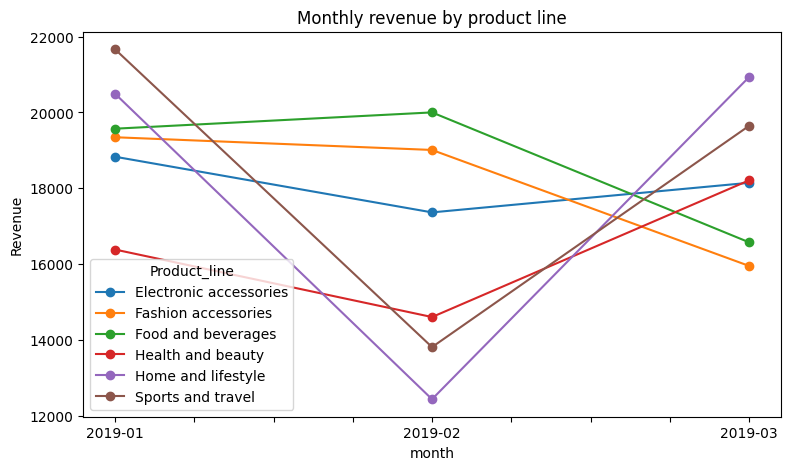

In [37]:
query1 = """
SELECT strftime('%Y-%m', Date) AS month,
       Product_line,
       SUM(Sales) AS revenue
FROM sales
GROUP BY month, Product_line
ORDER BY  revenue DESC;
"""

q1_result = pd.read_sql(query1,n)
print("\n--- Q1: Monthly revenue by product line ---")
print(q1_result.head(10))
 

pivot1 = q1_result.pivot(index="month", columns="Product_line", values="revenue")
pivot1.plot(kind="line", marker="o", figsize=(9, 5), title="Monthly revenue by product line")
plt.ylabel("Revenue")
plt.show()


--- Q2: Top 5 high-profit product lines ---
             Product_line  total_profit
0      Food and beverages   253988.5800
1       Sports and travel   249365.1675
2  Electronic accessories   245812.6425
3     Fashion accessories   245669.5250
4      Home and lifestyle   243661.0350


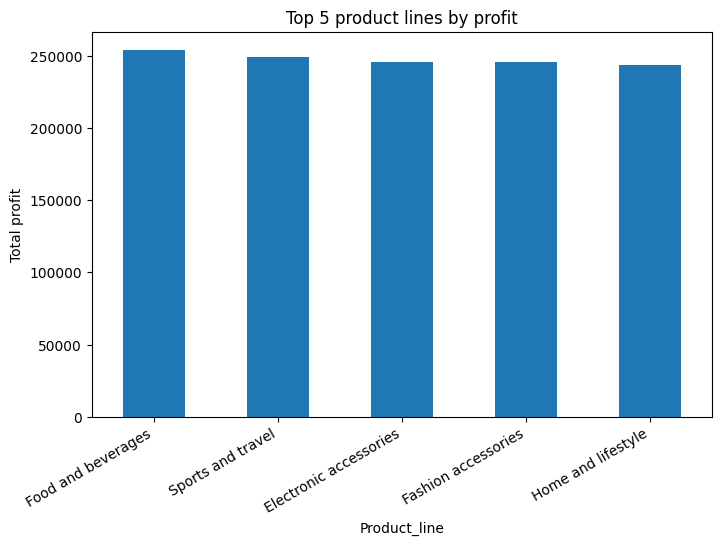

In [36]:
query2 = """
SELECT Product_line,
       SUM(grossincome) AS total_profit
FROM sales
GROUP BY Product_line
ORDER BY total_profit DESC
LIMIT 5;
"""
q2_result = pd.read_sql(query2, n)
print("\n--- Q2: Top 5 high-profit product lines ---")
print(q2_result)
 
q2_result.plot(kind="bar", x="Product_line", y="total_profit",
                figsize=(8, 5), legend=False, title="Top 5 product lines by profit")
plt.ylabel("Total profit")
plt.xticks(rotation=30, ha="right")
plt.show()


--- Q3: Customer rush by hour ---
   hour  num_transactions
0    10               101
1    11                90
2    12                89
3    1:               103
4    2:                83
5    3:               102
6    4:                77
7    5:                74
8    6:                93
9    7:               113
10   8:                75


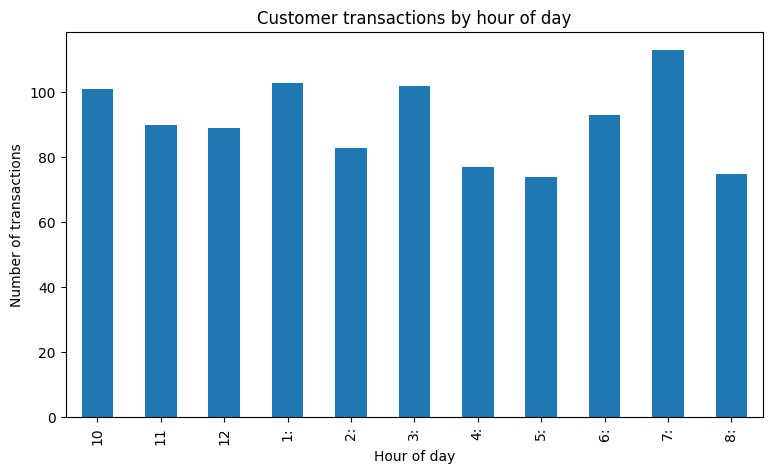

In [35]:
query3 = """
SELECT substr(Time, 1, 2) AS hour,
       COUNT(*) AS num_transactions
FROM sales
GROUP BY hour
ORDER BY hour;
"""
q3_result = pd.read_sql(query3, n)
print("\n--- Q3: Customer rush by hour ---")
print(q3_result)
 
q3_result.plot(kind="bar", x="hour", y="num_transactions",
                figsize=(9, 5), legend=False, title="Customer transactions by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Number of transactions")
plt.show()


--- Q4: Weekly revenue trend ---
       week  weekly_revenue
0   2019-00      17543.3895
1   2019-01      24461.1990
2   2019-02      28693.3605
3   2019-03      29286.8835
4   2019-04      28360.4475
5   2019-05      27101.8335
6   2019-06      25563.5940
7   2019-07      17328.6645
8   2019-08      29219.7150
9   2019-09      28418.8380
10  2019-10      23990.2215
11  2019-11      25120.5990
12  2019-12      17878.0035


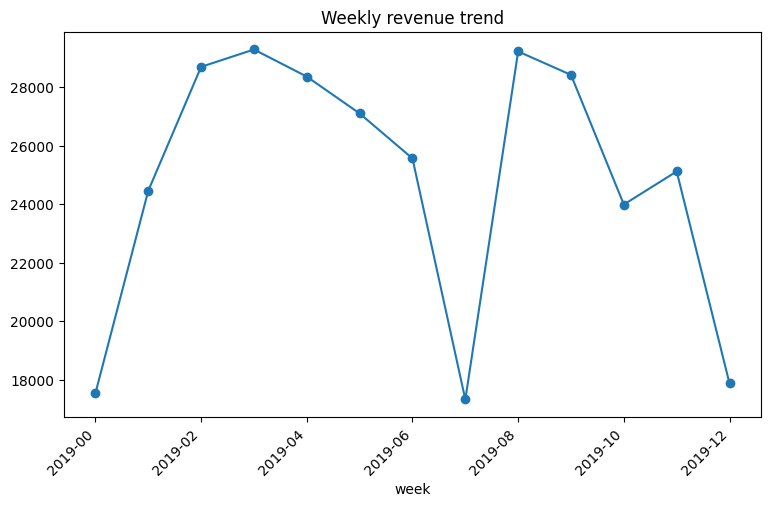

In [34]:
query4 = """
SELECT strftime('%Y-%W', Date) AS week,
       SUM(Sales) AS weekly_revenue
FROM sales
GROUP BY week
ORDER BY week;
"""
q4_result = pd.read_sql(query4,n)
print("\n--- Q4: Weekly revenue trend ---")
print(q4_result)
 
q4_result.plot(kind="line", x="week", y="weekly_revenue", marker="o",
                figsize=(9, 5), legend=False, title="Weekly revenue trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()


--- Q5: Quantity sold by product line month wise---
              Product_line    month  qty_sold
0        Sports and travel  2019-01       375
1       Home and lifestyle  2019-03       364
2       Food and beverages  2019-02       349
3       Home and lifestyle  2019-01       342
4      Fashion accessories  2019-01       336
5        Health and beauty  2019-03       334
6   Electronic accessories  2019-01       333
7   Electronic accessories  2019-03       325
8       Food and beverages  2019-01       325
9        Sports and travel  2019-03       319
10  Electronic accessories  2019-02       313
11     Fashion accessories  2019-02       295
12      Food and beverages  2019-03       278
13     Fashion accessories  2019-03       271
14       Health and beauty  2019-02       266
15       Health and beauty  2019-01       254
16       Sports and travel  2019-02       226
17      Home and lifestyle  2019-02       205

--- Recommended restock timing per product line ---
             Product

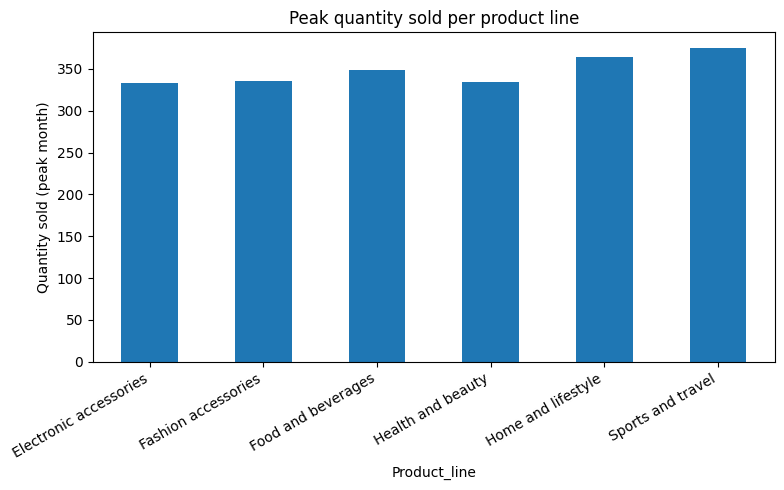

In [41]:
query5 = """
SELECT Product_line,
       strftime('%Y-%m', Date) AS month,
       SUM(Quantity) AS qty_sold
FROM sales
GROUP BY Product_line, month
ORDER BY qty_sold DESC;
"""
q5_result = pd.read_sql(query5,n)
print("\n--- Q5: Quantity sold by product line month wise---")
print(q5_result)

# "find the single peak month per product line"
restock_plan = q5_result.loc[q5_result.groupby("Product_line")["qty_sold"].idxmax()]
restock_plan = restock_plan.rename(columns={"month": "peak_demand_month"})
print("\n--- Recommended restock timing per product line ---")
print(restock_plan[["Product_line", "peak_demand_month", "qty_sold"]])
 
restock_plan.plot(kind="bar", x="Product_line", y="qty_sold",
                   figsize=(8, 5), legend=False, title="Peak quantity sold per product line")
plt.ylabel("Quantity sold (peak month)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("q5_restock_plan.png")
plt.show()

In [42]:
n.close()